# Bloqs チュートリアル

公式ドキュメント「Fundamentals」対応ノートブック

対応する公式ページ: [Bloqs チュートリアル (Fundamentals)](https://qualtran.readthedocs.io/en/latest/_infra/Bloqs-Tutorial.html)

## 概要

(ここに内容を記述)


### Basics

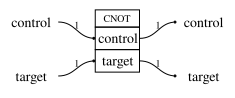

In [51]:
import attrs
from qualtran import Bloq, Signature, Register, QBit
from qualtran.drawing import show_bloq

@attrs.frozen
class CNOT(Bloq):
    @property
    def signature(self):
        return Signature([
            Register("control", QBit()),
            Register("target", QBit()),
        ])

cnot = CNOT()
show_bloq(cnot)


### Decomposing Bloqs

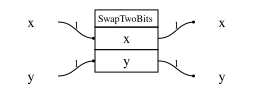

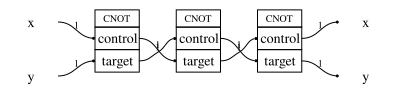

In [52]:
from qualtran import BloqBuilder

class SwapTwoBits(Bloq):
    @property
    def signature(self):
        return Signature([
            Register("x", QBit()),
            Register("y", QBit()),
        ])
        
    def build_composite_bloq(self, bb: BloqBuilder, *, x, y):
        x, y = bb.add(CNOT(), control=x, target=y)
        y, x = bb.add(CNOT(), control=y, target=x)
        x, y = bb.add(CNOT(), control=x, target=y)
        return {"x": x, "y": y}


swap = SwapTwoBits()
show_bloq(swap)
show_bloq(swap.decompose_bloq())

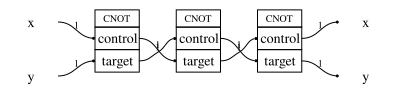

In [53]:
bb = BloqBuilder()
x = bb.add_register("x", 1)
y = bb.add_register("y", 1)
x, y = bb.add(CNOT(), control=x, target=y)
y, x = bb.add(CNOT(), control=y, target=x)
x, y = bb.add(CNOT(), control=x, target=y)
cbloq = bb.finalize(x=x, y=y)
show_bloq(cbloq)

### Quantum variables and Soquets

**No cloning theorem**

In [54]:
from qualtran import BloqError

bb = BloqBuilder()
x = bb.add_register("x", 1)
y = bb.add_register("y", 1)

try:
    _ = bb.add(CNOT(), control=x, target=x)
except BloqError as e:
    print(e)

LeftDangle.x is not an available Soquet for `CNOT.target`.


In [55]:
from qualtran import BloqError

bb = BloqBuilder()
x = bb.add_register("x", 1)
y = bb.add_register("y", 1)
x2, y2 = bb.add(CNOT(), control=x, target=y)

try:
    x3, y3 = bb.add(CNOT(), control=x, target=y)
except BloqError as e:
    print(e)

LeftDangle.x is not an available Soquet for `CNOT.control`.


**No deleting theorem**

In [56]:
bb = BloqBuilder()
x = bb.add_register('x', 1)
y = bb.add_register('y', 1)

bb.add_register_allowed = False

x2, y2 = bb.add(CNOT(), control=x, target=y)
x3, y3 = bb.add(CNOT(), control=x2, target=y2)

try:
    bb.finalize(x=x3)
except BloqError as e:
    print(e)

Finalizing requires a Soquet named `y`.


### Larger registers

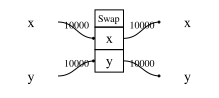

In [57]:
from qualtran import QAny

@attrs.frozen
class Swap(Bloq):
    n: int
    
    @property
    def signature(self):
        return Signature.build(x=self.n, y=self.n)

    def build_composite_bloq(
            self, bb: BloqBuilder, *, x: SoquetT, y: SoquetT
    ) -> Dict[str, SoquetT]:
        for i in range(self.n):
            x[i], y[i] = bb.add(SwapTwoBits(), x=x[i], y=y[i])
        return {'x': x, 'y': y}
        
show_bloq(Swap(n=10_000))

In [58]:
import traceback

try:
    cbloq = Swap(n=5).decompose_bloq()
except TypeError as e:
    print(traceback.format_exc())

Traceback (most recent call last):
  File "/var/folders/dc/bnxxzm_x02zb4jvc8zvn1cpw0000gn/T/ipykernel_84246/2679143270.py", line 4, in <module>
    cbloq = Swap(n=5).decompose_bloq()
  File "/Users/nsota/research/qualtran-tutorial/.venv/lib/python3.14/site-packages/qualtran/_infra/bloq.py", line 207, in decompose_bloq
    return _decompose_from_build_composite_bloq(self)
  File "/Users/nsota/research/qualtran-tutorial/.venv/lib/python3.14/site-packages/qualtran/_infra/bloq.py", line 71, in _decompose_from_build_composite_bloq
    out_soqs = bloq.build_composite_bloq(bb=bb, **initial_soqs)
  File "/var/folders/dc/bnxxzm_x02zb4jvc8zvn1cpw0000gn/T/ipykernel_84246/1641336029.py", line 15, in build_composite_bloq
    x[i], y[i] = bb.add(SwapTwoBits(), x=x[i], y=y[i])
                                         ~^^^
TypeError: 'Soquet' object is not subscriptable



In [59]:
from qualtran import QAny
arr_reg = Register("arr", QAny(32), shape=(3, 3))
print("total bits: ", arr_reg.total_bits())

total bits:  288


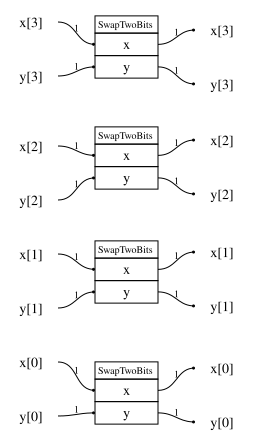

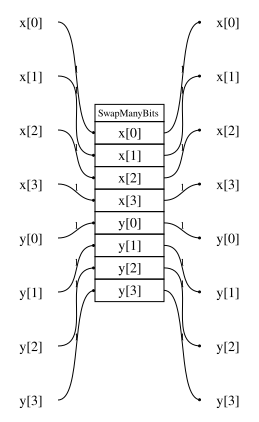

In [60]:
@attrs.frozen
class SwapManyBits(Bloq):
    n: int
    
    @property
    def signature(self):
        return Signature([
            Register('x', QBit(), shape=(self.n,)),
            Register('y', QBit(), shape=(self.n,)),
        ])

    def build_composite_bloq(
            self, bb: BloqBuilder, *, x: SoquetT, y: SoquetT
    ) -> Dict[str, SoquetT]:
        for i in range(self.n):
            x[i], y[i] = bb.add(SwapTwoBits(), x=x[i], y=y[i])
        return {'x': x, 'y': y}
        
cbloq = SwapManyBits(n=4).decompose_bloq()
show_bloq(cbloq)
show_bloq(SwapManyBits(n=4))

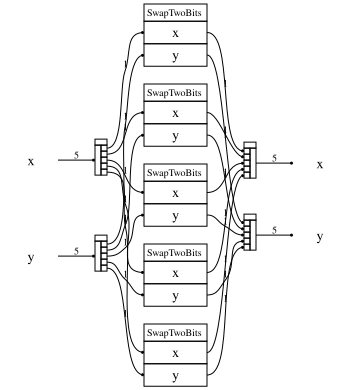

In [62]:
@attrs.frozen
class Swap(Bloq):
    n: int

    @property
    def signature(self):
        return Signature.build(x=self.n, y=self.n)

    def build_composite_bloq(
            self, bb: BloqBuilder, *, x: SoquetT, y: SoquetT
    ) -> Dict[str, SoquetT]:
        xs = bb.split(x)
        ys = bb.split(y)

        for i in range(self.n):
            xs[i], ys[i] = bb.add(SwapTwoBits(), x=xs[i], y=ys[i])
        return {
            'x': bb.join(xs),
            'y': bb.join(ys),
        }

cbloq = Swap(n=5).decompose_bloq()
show_bloq(cbloq)

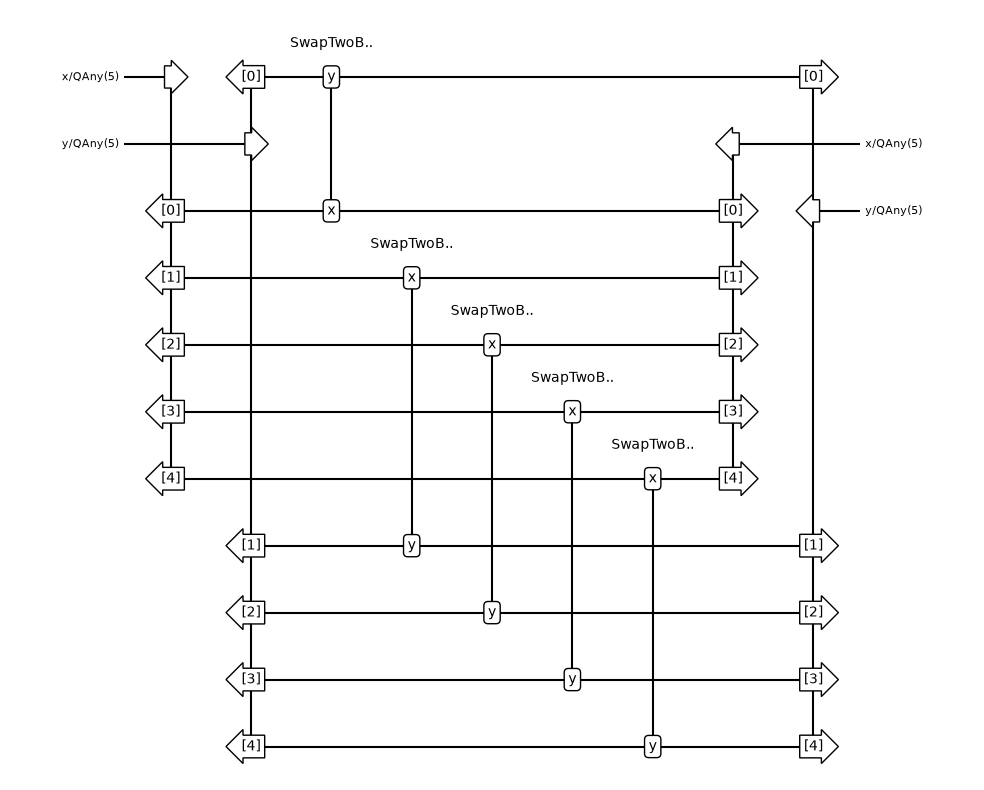

In [65]:
from qualtran.drawing import get_musical_score_data, draw_musical_score
msd = get_musical_score_data(cbloq)
fig, ax = draw_musical_score(msd)
fig.set_figwidth(10)

### Allocations and de-allocations

In [66]:
reg = Register("ctrl", QBit())
reg.side

<Side.THRU: 3>

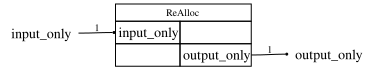

In [67]:
from qualtran import Side

@attrs.frozen
class ReAlloc(Bloq):
    @property
    def signature(self):
        return Signature([
            Register('input_only', QBit(), side=Side.LEFT),
            Register('output_only', QBit(), side=Side.RIGHT),
        ])
    
show_bloq(ReAlloc())

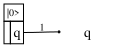

array([1.+0.j, 0.+0.j])

In [70]:
from qualtran.bloqs.basic_gates import ZeroState
show_bloq(ZeroState())
ZeroState().tensor_contract()

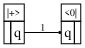

np.complex128(0.4999999999999999+0j)

In [72]:
from qualtran.bloqs.basic_gates import PlusState, ZeroEffect

bb = BloqBuilder()

q = bb.add(PlusState())
bb.add(ZeroEffect(), q=q)

cbloq = bb.finalize()
show_bloq(cbloq)
cbloq.tensor_contract() ** 2

### Algorithms

$$\vert{}e\rangle \vert{}x\rangle \mapsto \vert{}e\rangle \vert{}x \cdot 8^e \pmod{221}\rangle$$

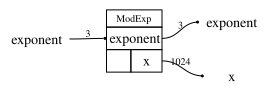

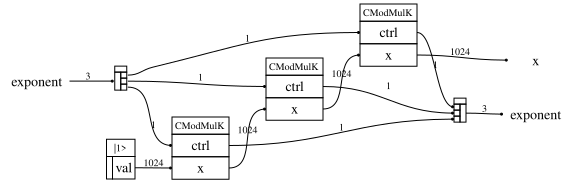

In [74]:
from qualtran.bloqs.cryptography.rsa import ModExp

mod_exp = ModExp(base=8, mod=13*17, exp_bitsize=3, x_bitsize=1024)
show_bloq(mod_exp)
show_bloq(mod_exp.decompose_bloq())